# 2. Exploratory Data Analysis

I tried to extract “sampled_box_builder.csv” using *cp* and *sync* but was unsuccessful.

Finally, I used *sync* from “/groceries/box_builder_dataset,” from where I downloaded “feature_frame.csv.”

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_features = pd.read_csv("../../data/raw/feature_frame.csv")

df_features.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   variant_id                        2880549 non-null  int64  
 1   product_type                      2880549 non-null  str    
 2   order_id                          2880549 non-null  int64  
 3   user_id                           2880549 non-null  int64  
 4   created_at                        2880549 non-null  str    
 5   order_date                        2880549 non-null  str    
 6   user_order_seq                    2880549 non-null  int64  
 7   outcome                           2880549 non-null  float64
 8   ordered_before                    2880549 non-null  float64
 9   abandoned_before                  2880549 non-null  float64
 10  active_snoozed                    2880549 non-null  float64
 11  set_as_regular                    2880549 non-nu

We have 27 variables, the vast majority of which are numerical (which will facilitate the use of models), and those that are not can perhaps be transformed into numerical (continuous or discrete) if necessary and if they add value to the possible use cases.

It would be interesting to define the meaning of the variable (since, for the use case, we do not know the origin of the dataset).

#### Definition of variables:

- variant_id : unique identifier
- product_type : type of product (category)
- created_at : creation date
- order_date : order date
- user_order_seq : order number (per user)
- outcome : event indicator (binary)
- ordered_before : previously ordered (history) (binary)
- abandoned_before : previously abandoned order (binary)
- active_snoozed : user on pause or inactive (binary)
- set_as_regular : marked as fair (binary)
- normalised_price : standard price
- discount_pct : discount applied

In [3]:
df_features.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [4]:
df_features.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
variant_id,2880549.0,3.401250e+13,2.786246e+11,3.361529e+13,3.380354e+13,3.397325e+13,3.428495e+13,3.454300e+13
order_id,2880549.0,2.978388e+12,2.446292e+11,2.807986e+12,2.875152e+12,2.902856e+12,2.922034e+12,3.643302e+12
user_id,2880549.0,3.750025e+12,1.775710e+11,3.046041e+12,3.745901e+12,3.812775e+12,3.874925e+12,5.029635e+12
user_order_seq,2880549.0,3.289342e+00,2.140176e+00,2.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,2.100000e+01
outcome,2880549.0,1.153669e-02,1.067876e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
ordered_before,2880549.0,2.113868e-02,1.438466e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
abandoned_before,2880549.0,6.092589e-04,2.467565e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
active_snoozed,2880549.0,2.290188e-03,4.780109e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
set_as_regular,2880549.0,3.629864e-03,6.013891e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
normalised_price,2880549.0,1.272808e-01,1.268378e-01,1.599349e-02,5.394416e-02,8.105178e-02,1.352670e-01,1.000000e+00


In [5]:
df_features.nunique()

variant_id                           976
product_type                          62
order_id                            3446
user_id                             1937
created_at                          3446
order_date                           149
user_order_seq                        20
outcome                                2
ordered_before                         2
abandoned_before                       2
active_snoozed                         2
set_as_regular                         2
normalised_price                     127
discount_pct                         526
vendor                               264
global_popularity                   5968
count_adults                           5
count_children                         4
count_babies                           2
count_pets                             5
people_ex_baby                         5
days_since_purchase_variant_id       142
avg_days_to_buy_variant_id           122
std_days_to_buy_variant_id           819
days_since_purch

In [6]:
df_features.duplicated().sum()

np.int64(0)

In [7]:
df_features["outcome"].value_counts(normalize=True)

outcome
0.0    0.988463
1.0    0.011537
Name: proportion, dtype: float64

We have a very unbalanced dataset for one of the events. If we set 0 as “no” (which would be the most logical), most orders were not completed.

### Analisys

In [8]:
df_features[df_features["outcome"] == 1]["product_type"].value_counts(normalize=True).head(10)

product_type
tinspackagedfoods           0.133877
longlifemilksubstitutes     0.054496
snacksconfectionery         0.052540
ricepastapulses             0.046190
cereal                      0.045829
condimentsdressings         0.045318
cookingingredientsoils      0.043873
dishwasherdetergent         0.043362
bathroomlimescalecleaner    0.036982
homebaking                  0.033040
Name: proportion, dtype: float64

In [9]:
df_features[df_features["outcome"] == 1]["vendor"].value_counts(normalize=True).head(15)

vendor
biona               0.067616
oatly               0.043603
ecover              0.039751
method              0.037313
treeoflife          0.028978
heinz               0.025397
mutti               0.020552
tonyschocolonely    0.018235
cooksco             0.017965
clearspring         0.013541
thecheekypanda      0.013361
symphony            0.013361
tatelyle            0.013361
plenty              0.013270
finish              0.012729
Name: proportion, dtype: float64

In [10]:
df_features[df_features["ordered_before"] == 1]["outcome"].value_counts(normalize=True)

outcome
0.0    0.835033
1.0    0.164967
Name: proportion, dtype: float64

In [11]:
df_features["discount_pct"].value_counts().sort_index()

discount_pct
-0.040161     1587
 0.000000     2367
 0.000953      430
 0.001252     4032
 0.001541      844
             ...  
 1.010101     6892
 1.013423    17230
 1.020202     3446
 1.132075     3446
 1.325301     3446
Name: count, Length: 526, dtype: int64

They cannot be base percentage discounts, as some exceed 100%, so they are likely to be applied to another price.

- Possible interpretations negative discount:

    The price increased compared to the base price.

    Discount calculation error.

    Difference between historical price and current price.

    Error or a discount greater than the purchase price (applied by a voucher or promotion). 

In [12]:
df_features["discount_pct"].describe()

count    2.880549e+06
mean     1.862744e-01
std      1.934480e-01
min     -4.016064e-02
25%      8.462238e-02
50%      1.169176e-01
75%      2.234637e-01
max      1.325301e+00
Name: discount_pct, dtype: float64

In [13]:
df_features[(df_features["ordered_before"] == 1) & (df_features["discount_pct"] < 0.0)]["outcome"].value_counts(normalize=True)

outcome
0.0    0.692308
1.0    0.307692
Name: proportion, dtype: float64

In [14]:
df_features[(df_features["ordered_before"] == 1) & (df_features["discount_pct"] > 1.3)]["outcome"].value_counts(normalize=True)

outcome
0.0    0.745098
1.0    0.254902
Name: proportion, dtype: float64

In [15]:
df_features[(df_features["ordered_before"] == 1) & (df_features["discount_pct"] > 1.2) & (df_features["count_children"] > 0)]["outcome"].value_counts(normalize=True)

outcome
1.0    0.529412
0.0    0.470588
Name: proportion, dtype: float64

In [16]:
df_features[(df_features["ordered_before"] == 1) & (df_features["discount_pct"] > 0) & (df_features["count_children"] > 0)]["outcome"].value_counts(normalize=True)

outcome
0.0    0.839407
1.0    0.160593
Name: proportion, dtype: float64

### Representations

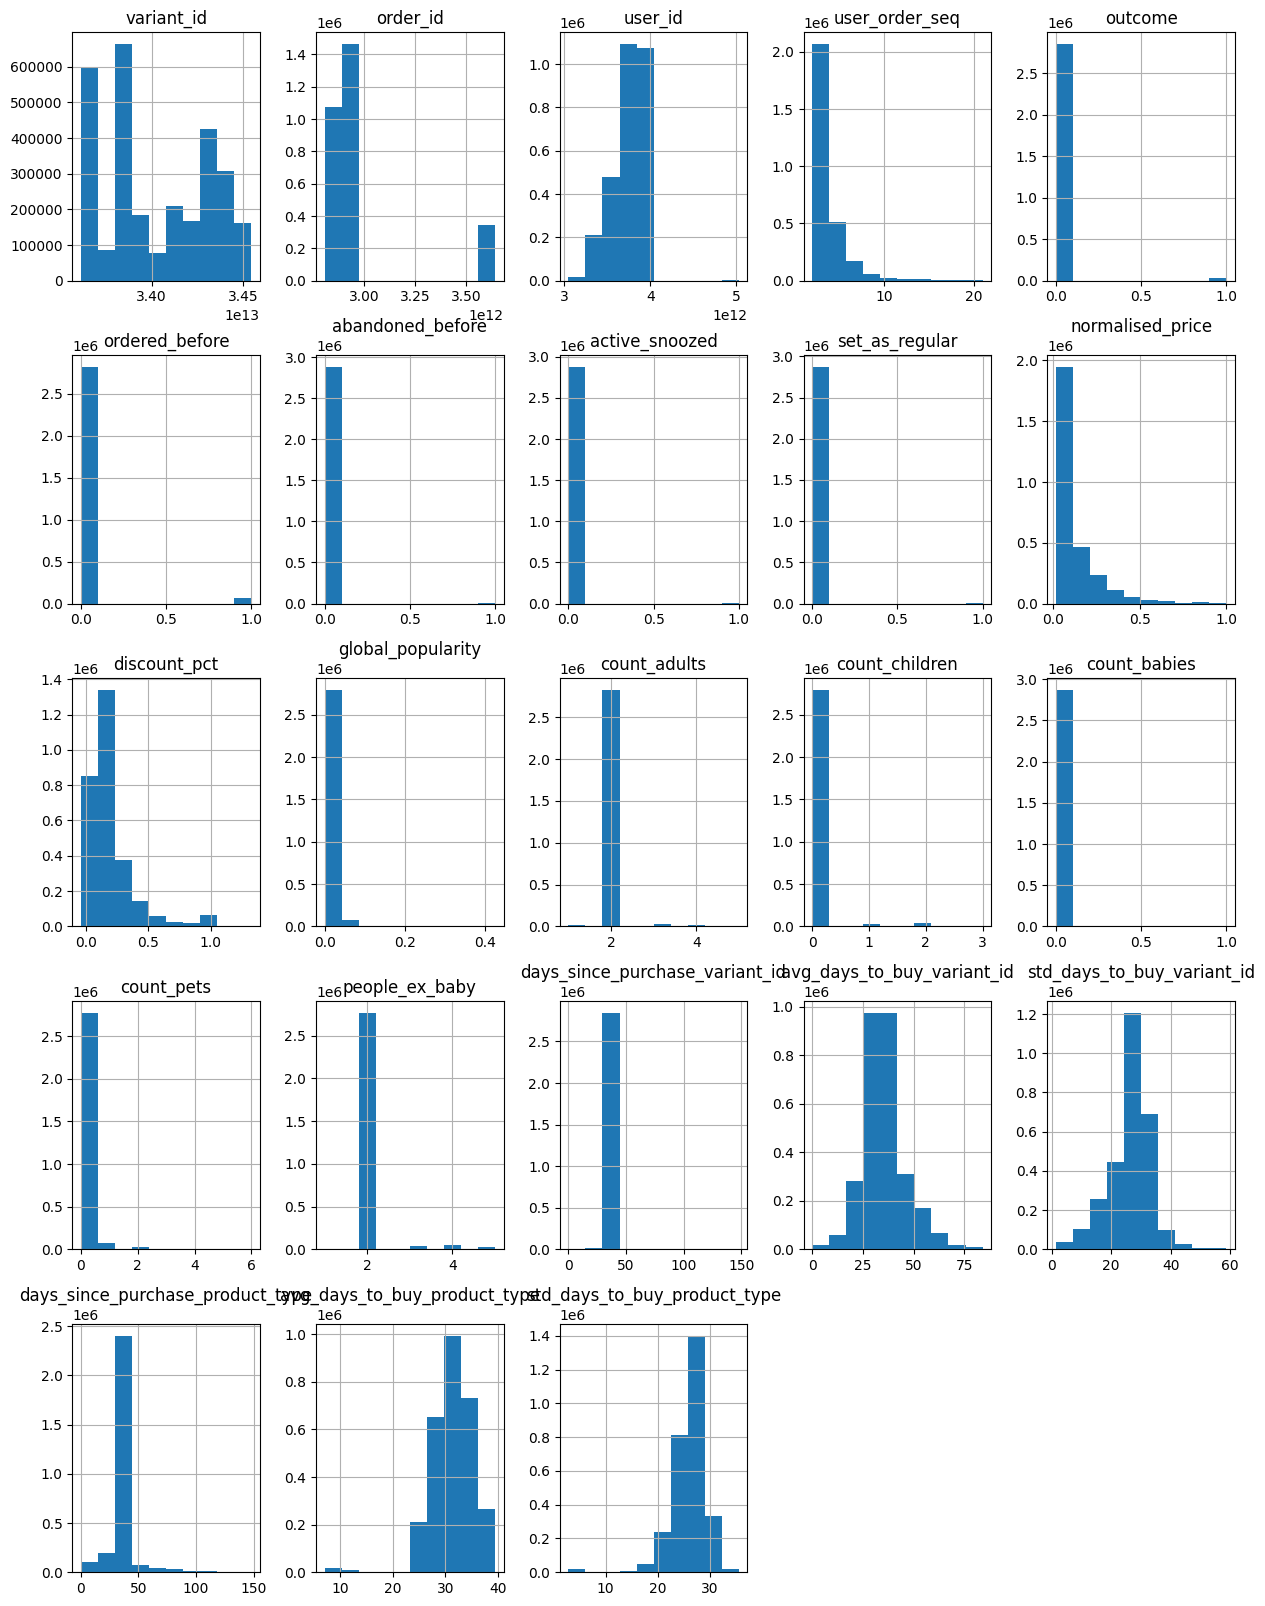

In [17]:
df_features.hist(figsize=(15, 20))
plt.show()

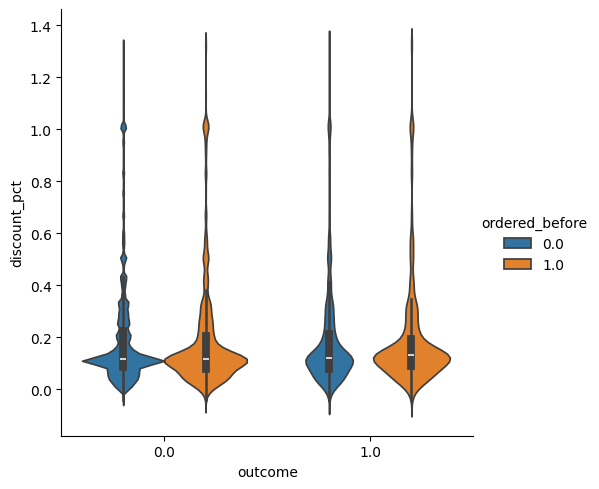

In [18]:
sns.catplot(data=df_features, x="outcome", y="discount_pct", kind="violin", hue="ordered_before")

/home/diego/zrive-ds/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


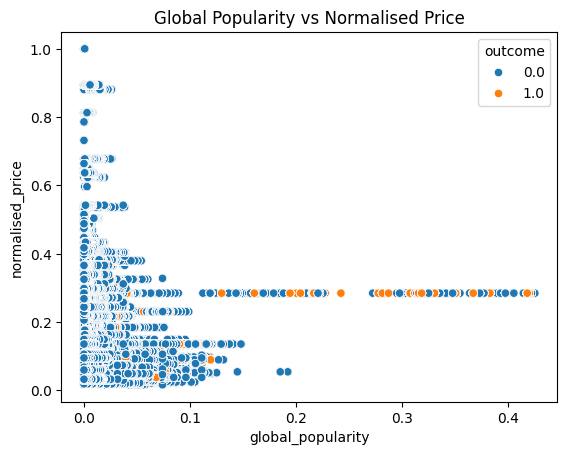

In [19]:
sns.scatterplot(data=df_features, x="global_popularity", y="normalised_price", hue="outcome")
plt.title("Global Popularity vs Normalised Price")
plt.show()

### Insights:

1. The target variable *outcome* is highly imbalanced.
2. Regular customers aren't swayed by discounts.
3. High discounts do not guarantee higher conversion rates.
4. Customers with children are more likely to be swayed by discounts.
5. Products with small discounts that are added to the cart for the first time are abandoned more frequently.
6. The majority of abandoned items are less popular and have a lower average price.